<a href="https://colab.research.google.com/github/Rut092/AI-Journey-Practice/blob/main/Article_Practice_05_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing the Libraries

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Create an Imbalanced Dataset

In [3]:
dataset = make_classification(n_samples=1000, n_features=20,weights=[0.95, 0.05], random_state=42)
print(dataset)

(array([[-0.6693561 , -0.19806908, -0.87076638, ..., -1.26733697,
         0.26173564,  1.01664321],
       [ 0.09337237,  0.78584826,  0.10575379, ..., -0.12270893,
         0.6934308 ,  0.91136272],
       [-0.90579721,  1.03575674,  0.29514098, ...,  0.83049813,
         0.95404926, -0.5782121 ],
       ...,
       [-0.20013455, -1.46108168,  1.79701652, ..., -1.50280171,
        -1.27473745,  1.60111869],
       [ 0.03935575,  0.24868361, -0.47532342, ...,  0.09912579,
         0.54269228,  1.20827474],
       [ 0.76921528,  0.47076539,  0.16994471, ...,  0.6561162 ,
         0.64333186, -2.02100232]]), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0

In [4]:
X_train, X_test, y_train, y_test = train_test_split(dataset[0], dataset[1], test_size=0.2, random_state=42)

## Train the Model

In [5]:
classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

RandomForestClassifier()

## Prediction of the Model

In [16]:
pred = classifier.predict(X_test)
print(f'Accuracy Score of the dataset comes down to : {accuracy_score(y_test, pred)*100}%')

Accuracy Score of the dataset comes down to : 96.0%


## How many cases we missed

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


              precision    recall  f1-score   support

    Safe (0)       0.96      1.00      0.98       189
   Fraud (1)       1.00      0.27      0.43        11

    accuracy                           0.96       200
   macro avg       0.98      0.64      0.70       200
weighted avg       0.96      0.96      0.95       200



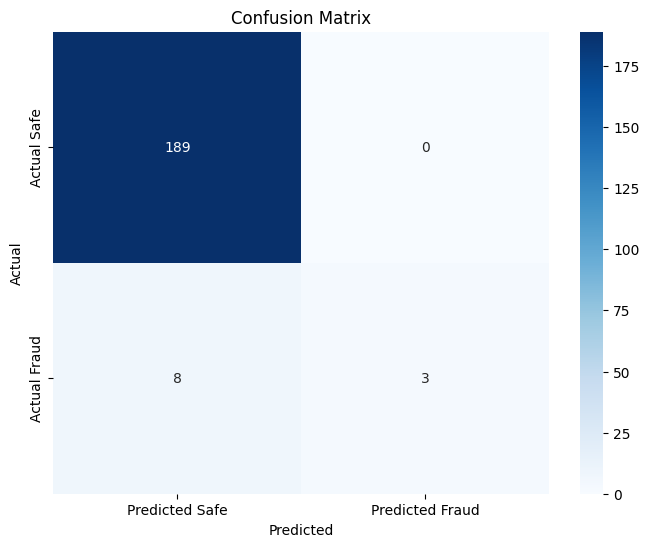

In [22]:
print(classification_report(y_test, pred, target_names=['Safe (0)', 'Fraud (1)']))


cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Safe', 'Predicted Fraud'],
            yticklabels=['Actual Safe', 'Actual Fraud'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## K-fold Validation

In [23]:
from sklearn.model_selection import cross_val_score

In [25]:
cv_score = cross_val_score(classifier,dataset[0],dataset[1],cv=5)
print(f"Scores across 5 tests are {cv_score}")

Scores across 5 tests are [0.975 0.97  0.95  0.975 0.96 ]
